# set up

In [7]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [6]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
sns.set_theme()

# Justifying trial type > instatanous state > instatanous speed

## Set up for 14 conditions and 3 areas 

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [4]:
# Load selected group_id
import pickle
with open('group_id_selected_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_selected_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [8]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [9]:
# Just to get a wider range of speed
start_time = -0.5
end_time = 1.0
padding = 0.1
V1_wider = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

V1_wider.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


## No speed

Negative log likelihood is: 67456.61
aic/2 is: 67487.61


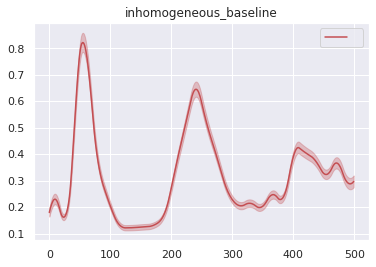

In [15]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Simple linear term of speed

Negative log likelihood is: 67281.68
aic/2 is: 67313.68


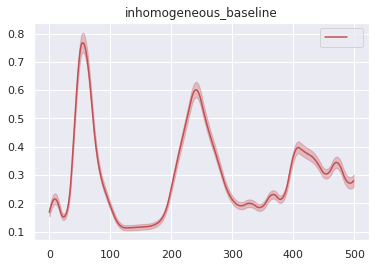

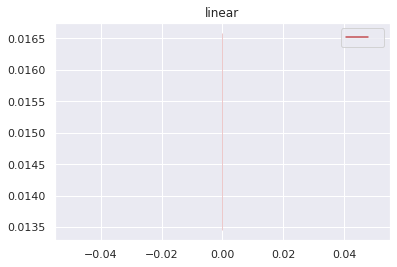

In [13]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('linear', smo, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Simple binary term of state

Negative log likelihood is: 67332.32
aic/2 is: 67364.32


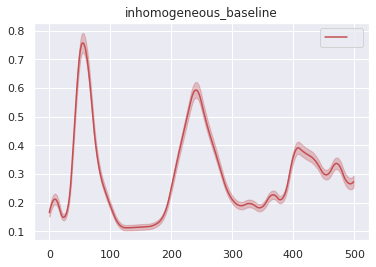

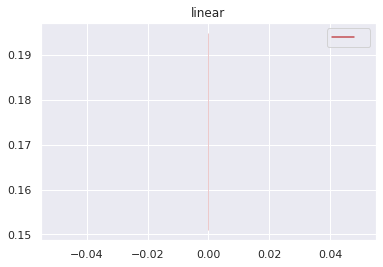

In [14]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
threshold = 1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('linear', instantaneous_state, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Time-varying linear term of speed

Negative log likelihood is: 66575.62
aic/2 is: 66637.62


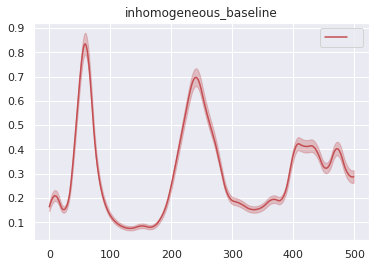

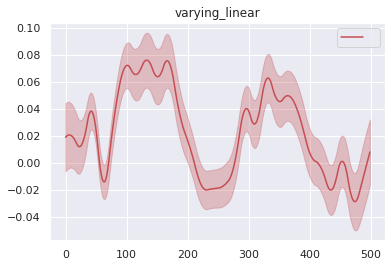

In [20]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Time-varying binary term of state

Negative log likelihood is: 66428.14
aic/2 is: 66490.14


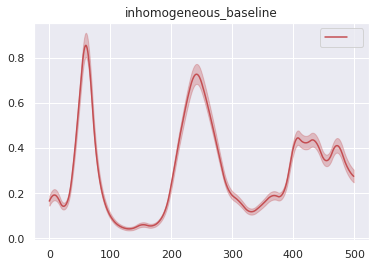

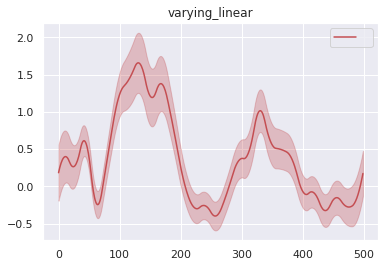

In [21]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('varying_linear', instantaneous_state, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Trial-wise binary term of state

Negative log likelihood is: 66160.24
aic/2 is: 66222.24


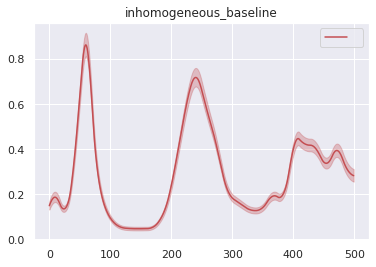

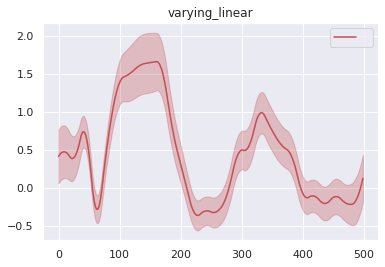

In [22]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
trial_state = np.zeros_like(smo)
for i in range(trial_state.shape[1]):
    if V1.running_trial_index[i]:
        trial_state[:,i] = 1.0

model.add_effect('varying_linear', trial_state, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Two-way couping

Negative log likelihood is: 67276.68
aic/2 is: 67312.68


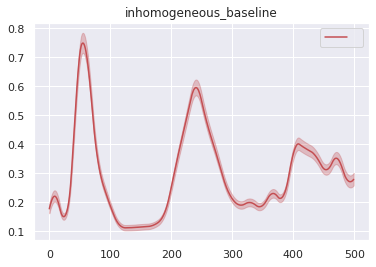

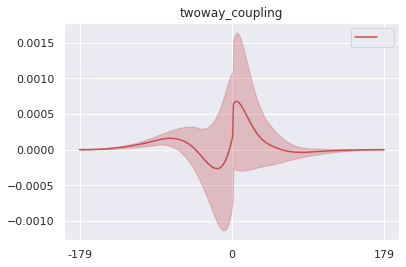

In [24]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('twoway_coupling', smo, peaks_max=40, num=3, nonlinear=0.4)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

# Fit six area with 